# SHL Grammar Scoring

Predict the grammar score (0-5) of a 45-60 second spoken English clip.

**Approach:** Whisper transcripts + hand-crafted grammar and fluency features + pretrained text and audio embeddings, fed to ridge regression. Feature groups are chosen by 5-fold cross-validation.

**Where things run**
- `kaggle_transcribe.ipynb`, `kaggle_whisper_encoder.ipynb` (Kaggle GPU, once): transcripts, embeddings, acceptability scores, cached in `outputs/`
- this notebook (CPU, a few minutes): features, model, evaluation, `outputs/submission.csv`

**Contents**
1. Pipeline
2. Setup
3. Data
4. Transcripts
5. Hand-crafted features
6. Embeddings
7. Choosing feature groups
8. One ridge vs one ridge per group
9. Final model: CV and training RMSE
10. Interpretation
11. Submission
12. Summary

## 1. Pipeline

```
                 Kaggle GPU (once)                              This notebook (CPU)
 .wav clip ─┬─► Whisper medium.en ─► transcript ─┬─► hand-crafted text features ─┐
            │                                    ├─► LanguageTool error rates ───┤
            │                                    ├─► CoLA acceptability ─────────┤
            │                                    └─► MPNet / DeBERTa embedding ──┼─► ridge regression ─► clip to 0..5
            ├─► timing stats (duration, pauses) ─────────────────────────────────┤
            ├─► WavLM audio embedding ───────────────────────────────────────────┤
            └─► Whisper large-v3 encoder embedding ──────────────────────────────┘
```

- **Whisper** for transcription: accurate on accented English, fast on a free GPU.
- **Hand-crafted features** map to the rubric: sentence length and subordinate clauses (structure), LanguageTool and CoLA scores (accuracy), speech rate, pauses, fillers and repetitions (fluency).
- **Embeddings** summarise a whole transcript or recording in one vector and pick up patterns simple counts miss.
- **Ridge regression**: linear, with a penalty on large weights so it does not overfit ~730 clips with thousands of inputs.
- **5-fold cross-validation** is the only basis for modelling choices.

## 2. Setup

In [1]:
import random
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))  # make the src/ package importable

from src.data import OUTPUT_DIR, load_dataset, load_embedding, load_row_features, write_submission
from src.features import build_handcrafted, languagetool_features, remove_asr_loops
from src.train import (SEED, GroupBlend, compare_feature_sets, cross_validate, make_model,
                       pearson, predict_clipped, rmse)

random.seed(SEED)
np.random.seed(SEED)

# Plot style: one accent colour, a second only when two things are compared, grey reference lines.
BLUE, ORANGE, INK, MUTED, GRID, LIGHT_BLUE = "#2a78d6", "#eb6834", "#0b0b0b", "#52514e", "#e6e5e0", "#cde2fb"
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": MUTED, "axes.labelcolor": INK, "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": MUTED, "ytick.color": MUTED, "font.size": 9.5, "legend.frameon": False,
})
pd.set_option("display.precision", 3)

## 3. Data

`load_dataset` joins the Kaggle transcripts with the labels in `data/train.csv`, keyed by split and file name (train and test reuse names like `audio_19.wav`).

Whisper got stuck repeating a phrase on 5 clips ("tap tap tap ..." hundreds of times). Runs of the same phrase 4+ times in a row are collapsed to one copy before any feature is built.

In [2]:
clips, sub_columns = load_dataset()

cleaned = clips["transcript"].map(remove_asr_loops)
print(f"Transcripts with a Whisper loop removed: {(cleaned != clips['transcript']).sum()}")
clips["transcript"] = cleaned

is_train = (clips["split"] == "train").to_numpy()
train = clips[is_train].reset_index(drop=True)
print(f"Labelled clips: {is_train.sum()}, test clips: {(~is_train).sum()}")

file column 'filename', score column 'label'


Transcripts with a Whisper loop removed: 5
Labelled clips: 769, test clips: 216


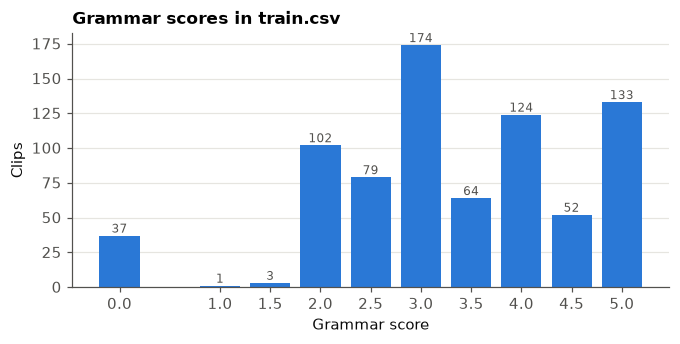

In [3]:
counts = train["label"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(counts.index, counts.values, width=0.4, color=BLUE)
for score, n in counts.items():
    ax.annotate(str(n), (score, n), xytext=(0, 2), textcoords="offset points", ha="center", color=MUTED, fontsize=8)
ax.set(title="Grammar scores in train.csv", xlabel="Grammar score", ylabel="Clips", xticks=counts.index)
ax.grid(axis="x", visible=False)
plt.show()

### The score-0 clips

37 clips are scored 0, and they do not look like the rest of the data:
- they are the only clips with ids above 784 (`audio_5037` to `audio_5073`), an extra batch added to train
- they have no silence at all (voiced ratio about 1.0), which points to constant background noise

The check below trains a small classifier on the WavLM audio embedding to tell score-0 clips from the others, then applies it to the test set.

In [4]:
is_zero = (train["label"] == 0).to_numpy()
file_num = train["file_id"].str.extract(r"(\d+)")[0].astype(int)
voiced_ratio = train["voiced_sec"] / train["duration_sec"]
display(pd.DataFrame({
    "clips": [is_zero.sum(), (~is_zero).sum()],
    "file id range": [f"{file_num[is_zero].min()}-{file_num[is_zero].max()}",
                      f"{file_num[~is_zero].min()}-{file_num[~is_zero].max()}"],
    "median voiced ratio": [voiced_ratio[is_zero].median(), voiced_ratio[~is_zero].median()],
}, index=["score 0", "score > 0"]))

wavlm_avg = load_embedding("audio_wavlm", clips)[:, 1:].mean(axis=1)  # average of transformer layers 1-12
detector = make_pipeline(StandardScaler(), LogisticRegression(C=0.1, max_iter=5000))
p_oof = cross_val_predict(detector, wavlm_avg[is_train], is_zero, cv=5, method="predict_proba")[:, 1]
p_test = detector.fit(wavlm_avg[is_train], is_zero).predict_proba(wavlm_avg[~is_train])[:, 1]
print(f"Score-0 detector: CV AUC {roc_auc_score(is_zero, p_oof):.3f}, "
      f"score-0 clips caught {(p_oof[is_zero] > 0.5).sum()}/{is_zero.sum()}, "
      f"other clips flagged {(p_oof[~is_zero] > 0.5).sum()}")
print(f"Test clips that look like the score-0 batch: {(p_test > 0.5).sum()} of {len(p_test)} "
      f"(max probability {p_test.max():.2f})")

,clips,file id range,median voiced ratio
score 0,37,5037-5073,1.00
score > 0,732,0-784,0.71


Score-0 detector: CV AUC 1.000, score-0 clips caught 37/37, other clips flagged 0
Test clips that look like the score-0 batch: 0 of 216 (max probability 0.00)


The score-0 batch is perfectly separable and no test clip resembles it. Keeping it would teach the model a pattern that never appears at test time, and the CV numbers would describe a different population than the test set. **These 37 clips are left out of training and evaluation.** Everything below uses the remaining 732 clips.

In [5]:
train_mask = is_train & (clips["label"] > 0).to_numpy()  # rows of `clips` used for training
train = clips[train_mask].reset_index(drop=True)
y = train["label"].to_numpy()
scores = np.sort(train["label"].unique())

print(f"Training clips: {len(y)}, score mean {y.mean():.3f}, std {y.std():.3f}")
print(f"Baseline: predicting the mean for every clip gives RMSE = std = {y.std():.3f}")

Training clips: 732, score mean 3.481, std 1.014
Baseline: predicting the mean for every clip gives RMSE = std = 1.014


## 4. Transcripts

One transcript from the low, middle and high end of the scale.

In [6]:
for score in [scores.min(), scores[len(scores) // 2], scores.max()]:
    text = train.loc[train["label"] == score, "transcript"].iloc[0]
    print(f"[score {score}] {text[:600]}{'...' if len(text) > 600 else ''}\n")

[score 1.0] As a young child, one of the most exciting place to be was the playground. It was a place with the rules of classrooms and the structure and warming of schools has been played well in our like the school days. We need to play very good sports in our playgrounds and we have lots of injuries in that our school time. So at the time just we played lot of things, even we have got injuries in that. So we were selected for the playgrounds while playing volleyballs, then online crickets. While on that only we are just selected from school side in a playground. We are just lots of friends with the play...

[score 3.0] The playground is very, very beautiful and fun. There are playthings like the miracle round, the swing. The students usually enjoy the swing. It has to be like, it's more like a game of pay because one sits on it and the other will have to push and the male goes around and climbs on it. Most of them play football. Some parks parks, while others play swing. Some of the 

## 5. Hand-crafted features

| Feature | Measures | Rubric link |
|---|---|---|
| `n_words`, `words_per_minute` | how much and how fast the speaker talks | fluency |
| `words_per_sentence` | average sentence length | sentence structure |
| `subordinator_rate` | *because, although, which ...* per 100 words | complex structures (levels 4-5) |
| `mean_word_length`, `lexical_diversity` | vocabulary range (Guiraud's index: unique words / sqrt(words)) | general proficiency |
| `filler_rate`, `repetition_rate` | *um, uh* and immediate repeats per 100 words | hesitation, self-correction |
| `voiced_ratio`, `long_pauses_per_minute` | share of the clip with speech, pauses of 0.5 s or more | fluency |
| `cola_mean`, `cola_min`, `cola_frac_bad` | sentence acceptability from RoBERTa fine-tuned on CoLA | grammatical accuracy |
| `lt_grammar_rate`, `lt_other_rate` | LanguageTool errors per 100 words | grammatical accuracy |

LanguageTool spelling, casing, punctuation and typography matches are ignored: those come from the transcription, not the speaker. Results are cached in `outputs/languagetool_features.csv`, so Java is only needed on the first run.

In [7]:
lt = languagetool_features(clips, OUTPUT_DIR / "languagetool_features.csv")
cola = load_row_features("cola_features.csv", clips)
handcrafted = build_handcrafted(clips, cola, lt)

hc_train = handcrafted[train_mask].reset_index(drop=True)
hc_train.describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
n_words,96.537,27.201,21.000,154.000
words_per_sentence,24.108,19.371,5.667,141.000
mean_word_length,4.245,0.407,3.343,5.873
lexical_diversity,5.908,0.891,3.491,8.573
filler_rate,0.028,0.355,0.000,8.421
repetition_rate,0.283,0.702,0.000,5.634
subordinator_rate,1.563,1.498,0.000,8.696
words_per_minute,104.943,27.875,20.974,206.348
voiced_ratio,0.704,0.143,0.038,1.000
long_pauses_per_minute,9.349,5.299,0.000,25.968


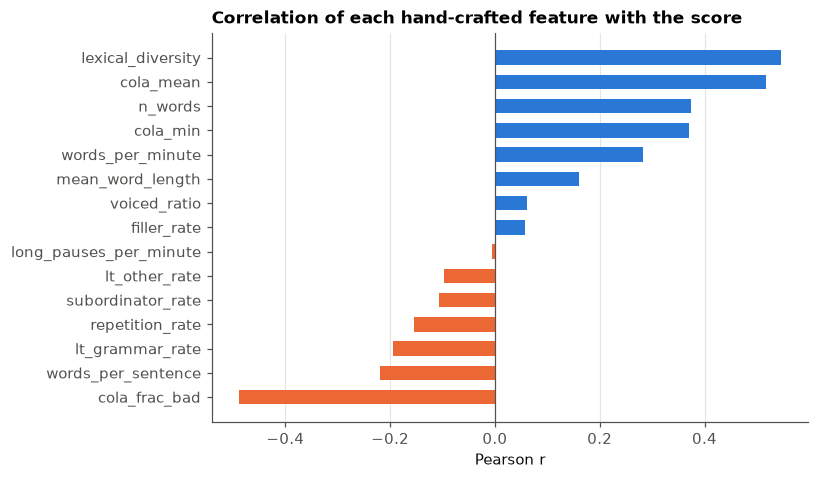

In [8]:
# Pearson r of each feature with the score, one feature at a time
corr = hc_train.apply(lambda col: pearson(y, col.fillna(col.median()))).sort_values()

fig, ax = plt.subplots(figsize=(7, 4.6))
ax.barh(corr.index, corr.values, color=[ORANGE if v < 0 else BLUE for v in corr.values], height=0.6)
ax.axvline(0, color=MUTED, linewidth=0.8)
ax.set(title="Correlation of each hand-crafted feature with the score", xlabel="Pearson r")
ax.grid(axis="y", visible=False)
plt.show()

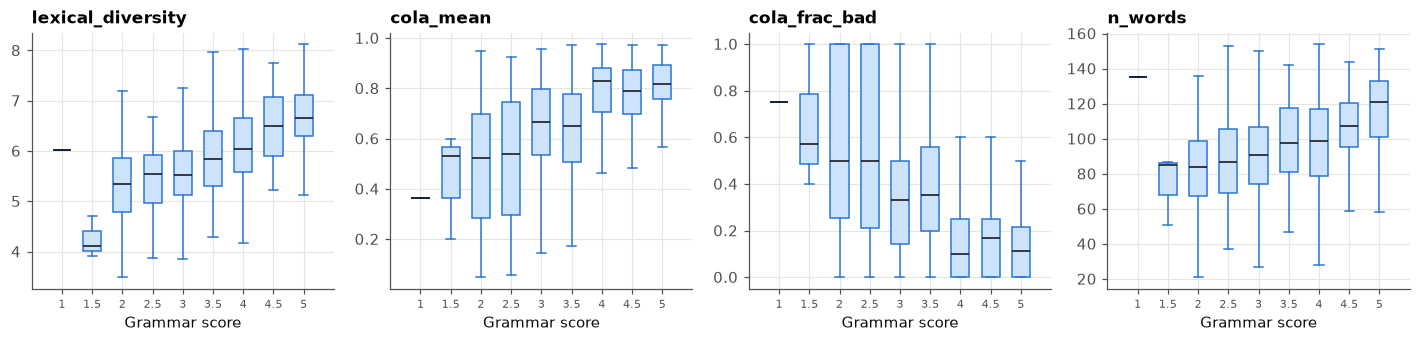

In [9]:
# The four strongest features against the score
top4 = corr.abs().sort_values(ascending=False).index[:4]

fig, axes = plt.subplots(1, 4, figsize=(13, 3.2))
for ax, feat in zip(axes, top4):
    groups = [hc_train.loc[y == s, feat].dropna() for s in scores]
    ax.boxplot(groups, positions=scores, widths=0.3, patch_artist=True, showfliers=False,
               boxprops=dict(facecolor=LIGHT_BLUE, edgecolor=BLUE), medianprops=dict(color=INK),
               whiskerprops=dict(color=BLUE), capprops=dict(color=BLUE))
    ax.set(title=feat, xlabel="Grammar score")
    ax.set_xticks(scores, [f"{s:g}" for s in scores], fontsize=7)
fig.tight_layout()
plt.show()

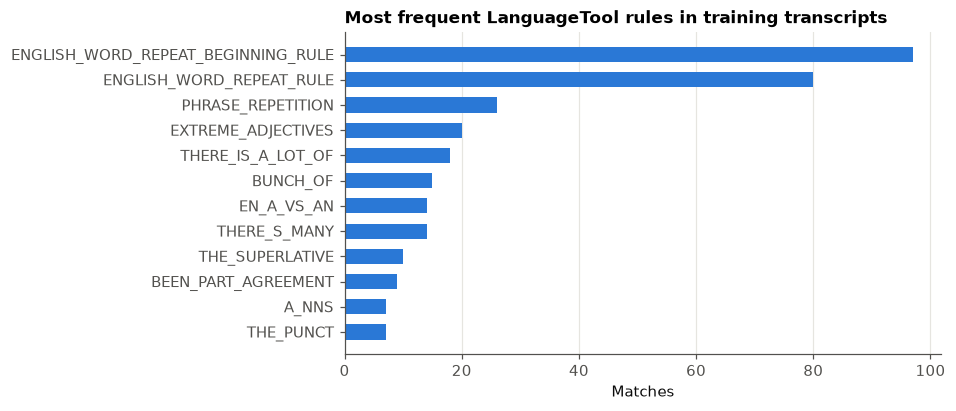

In [10]:
# Most frequent LanguageTool rules: what kind of errors the checker sees
rule_counts = Counter(r for rules in lt.loc[train_mask, "lt_rules"] for r in str(rules).split(";") if r)
top_rules = pd.Series(dict(rule_counts.most_common(12))).sort_values()

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.barh(top_rules.index, top_rules.values, color=BLUE, height=0.6)
ax.set(title="Most frequent LanguageTool rules in training transcripts", xlabel="Matches")
ax.grid(axis="y", visible=False)
plt.show()

## 6. Embeddings

One vector per clip from each pretrained model, computed on Kaggle:

| Group | Model | Size | Input |
|---|---|---|---|
| MPNet text | `all-mpnet-base-v2` | 768 | transcript |
| DeBERTa text | `deberta-v3-large`, token vectors averaged | 1024 | transcript |
| WavLM audio | `wavlm-base-plus`, frames averaged over time, layers 1-12 averaged | 768 | audio |
| Whisper audio | `whisper-large-v3` encoder, frames averaged over time, layers 4-32 (every 4th) averaged | 1280 | audio |

Averaging layers is a simple default that avoids tuning a layer choice. A group whose file is missing is skipped.

In [11]:
feature_groups = {"Hand-crafted": handcrafted.to_numpy(dtype=float),
                  "MPNet text": load_embedding("text_mpnet", clips),
                  "DeBERTa text": load_embedding("text_deberta", clips),
                  "WavLM audio": wavlm_avg}
if (OUTPUT_DIR / "emb_audio_whisper.npz").exists():
    # saved layers are 0, 4, ..., 32; index 0 is the input embedding, so average the rest
    feature_groups["Whisper audio"] = load_embedding("audio_whisper", clips)[:, 1:].mean(axis=1)
else:
    print("Whisper audio: outputs/emb_audio_whisper.npz not found, skipped")

for name, X in feature_groups.items():
    print(f"{name:14s} {X.shape[1]:5d} features")

Hand-crafted      15 features
MPNet text       768 features
DeBERTa text    1024 features
WavLM audio      768 features
Whisper audio   1280 features


## 7. Choosing feature groups

Same model (ridge, penalty picked by leave-one-out inside each training fold) and same 5 stratified folds for every combination. Each clip gets a prediction from a model that never saw it; RMSE and Pearson are computed on those out-of-fold predictions.

**Rule:** lowest CV RMSE, but fewer groups win unless the larger set is better by more than 0.005.

In [12]:
TOLERANCE = 0.005

candidates = [
    ["Hand-crafted"], ["MPNet text"], ["DeBERTa text"], ["WavLM audio"], ["Whisper audio"],
    ["Hand-crafted", "DeBERTa text"],
    ["Hand-crafted", "DeBERTa text", "WavLM audio"],
    ["Hand-crafted", "DeBERTa text", "Whisper audio"],
    ["Hand-crafted", "DeBERTa text", "WavLM audio", "Whisper audio"],
    ["Hand-crafted", "MPNet text", "DeBERTa text", "WavLM audio", "Whisper audio"],
]
candidates = [c for c in candidates if all(g in feature_groups for g in c)]
feature_sets = {" + ".join(c): np.hstack([feature_groups[g][train_mask] for g in c]) for c in candidates}

ablation, _ = compare_feature_sets(feature_sets, y)
ablation["n_groups"] = [len(c) for c in candidates]

within = ablation[ablation["cv_rmse"] <= ablation["cv_rmse"].min() + TOLERANCE]
chosen_set = within.sort_values(["n_groups", "cv_rmse"]).index[0]  # simplest set close to the best
chosen_groups = chosen_set.split(" + ")
print("Chosen feature groups:", chosen_set)
ablation.sort_values("cv_rmse")

Chosen feature groups: Hand-crafted + DeBERTa text + WavLM audio + Whisper audio


,n_features,cv_rmse,cv_rmse_fold_std,cv_pearson,n_groups
features,,,,,
Hand-crafted + DeBERTa text + WavLM audio + Whisper audio,3087,0.520,0.036,0.859,4
Hand-crafted + DeBERTa text + Whisper audio,2319,0.525,0.030,0.856,3
Hand-crafted + MPNet text + DeBERTa text + WavLM audio + Whisper audio,3855,0.529,0.040,0.854,5
Hand-crafted + DeBERTa text + WavLM audio,1807,0.532,0.043,0.852,3
Whisper audio,1280,0.549,0.029,0.842,1
WavLM audio,768,0.582,0.037,0.819,1
Hand-crafted + DeBERTa text,1039,0.596,0.057,0.809,2
DeBERTa text,1024,0.599,0.055,0.807,1
Hand-crafted,15,0.753,0.036,0.670,1


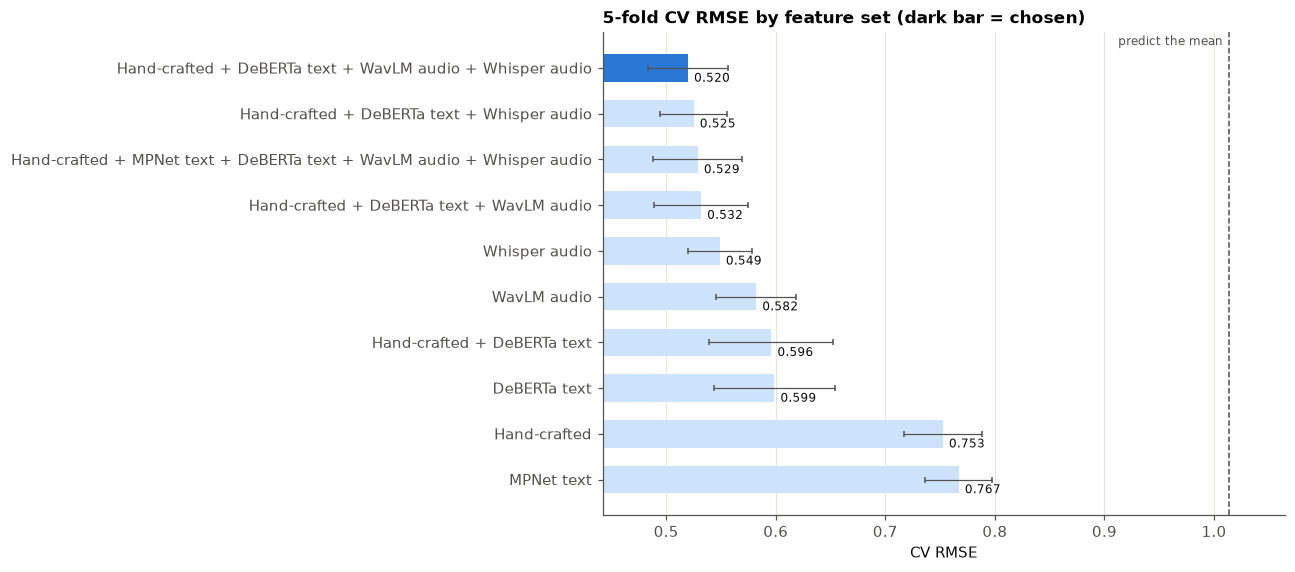

In [13]:
order = ablation.sort_values("cv_rmse", ascending=False)
baseline = y.std()

fig, ax = plt.subplots(figsize=(8, 0.45 * len(order) + 1.2))
ax.barh(order.index, order["cv_rmse"], xerr=order["cv_rmse_fold_std"], height=0.6,
        color=[BLUE if name == chosen_set else LIGHT_BLUE for name in order.index],
        error_kw=dict(ecolor=MUTED, lw=0.8, capsize=2))
ax.axvline(baseline, color=MUTED, linestyle="--", linewidth=1)
ax.annotate("predict the mean", (baseline, len(order) - 0.5), xytext=(-4, 0), textcoords="offset points",
            ha="right", color=MUTED, fontsize=8)
for i, v in enumerate(order["cv_rmse"]):
    ax.annotate(f"{v:.3f}", (v, i), xytext=(4, -9), textcoords="offset points", color=INK, fontsize=8)
ax.set(title="5-fold CV RMSE by feature set (dark bar = chosen)", xlabel="CV RMSE",
       xlim=(order["cv_rmse"].min() * 0.85, baseline * 1.05))
ax.grid(axis="y", visible=False)
plt.show()

## 8. One ridge vs one ridge per group

In one ridge, a single penalty has to suit 15 hand-crafted features and over a thousand embedding dimensions at once. The alternative fits one ridge per group and combines their predictions with non-negative weights, learned from each group's out-of-fold predictions inside the training fold. The blend is kept only if it beats the single ridge by more than the same 0.005.

In [14]:
X_all = np.hstack([feature_groups[g] for g in chosen_groups])
X_train, X_test = X_all[train_mask], X_all[~is_train]
group_sizes = [feature_groups[g].shape[1] for g in chosen_groups]

model_options = {"One ridge": make_model}
if len(chosen_groups) > 1:
    model_options["One ridge per group, blended"] = lambda: GroupBlend(group_sizes)
cv_runs = {name: cross_validate(X_train, y, fn) for name, fn in model_options.items()}

comparison = pd.DataFrame({name: {"cv_rmse": rmse(y, oof), "cv_pearson": pearson(y, oof)}
                           for name, (oof, _) in cv_runs.items()}).T
single_is_close = comparison.loc["One ridge", "cv_rmse"] <= comparison["cv_rmse"].min() + TOLERANCE
final_name = "One ridge" if single_is_close else comparison["cv_rmse"].idxmin()
model_fn = model_options[final_name]
oof, fold_table = cv_runs[final_name]
print("Final model:", final_name)
comparison

Final model: One ridge per group, blended


,cv_rmse,cv_pearson
One ridge,0.520,0.859
"One ridge per group, blended",0.512,0.864


## 9. Final model: CV and training RMSE

The final model is fitted once on all 732 training clips. The training RMSE is measured on those same clips, so it is optimistic. The CV RMSE is the estimate for unseen speakers.

In [15]:
final_model = model_fn().fit(X_train, y)
train_pred = predict_clipped(final_model, X_train)

results = pd.DataFrame({
    "RMSE": [rmse(y, oof), rmse(y, train_pred), y.std()],
    "Pearson r": [pearson(y, oof), pearson(y, train_pred), np.nan],
}, index=["5-fold CV (out-of-fold)", "Training set (fitted on all training clips)", "Baseline: predict the mean"])

print(f"Features: {chosen_set} ({X_all.shape[1]} columns), model: {final_name}")
print(f"\nTRAINING RMSE: {rmse(y, train_pred):.4f}")
print(f"CV RMSE:       {rmse(y, oof):.4f}  (fold mean {fold_table['rmse'].mean():.4f} +/- {fold_table['rmse'].std():.4f})")
print(f"CV Pearson r:  {pearson(y, oof):.4f}\n")
display(results.round(4))
fold_table.round(4)

Features: Hand-crafted + DeBERTa text + WavLM audio + Whisper audio (3087 columns), model: One ridge per group, blended

TRAINING RMSE: 0.3708
CV RMSE:       0.5120  (fold mean 0.5110 +/- 0.0342)
CV Pearson r:  0.8636



,RMSE,Pearson r
5-fold CV (out-of-fold),0.512,0.864
Training set (fitted on all training clips),0.371,0.933
Baseline: predict the mean,1.014,NaN


,fold,rmse,pearson
0,1,0.560,0.828
1,2,0.489,0.872
2,3,0.508,0.867
3,4,0.525,0.867
4,5,0.472,0.885


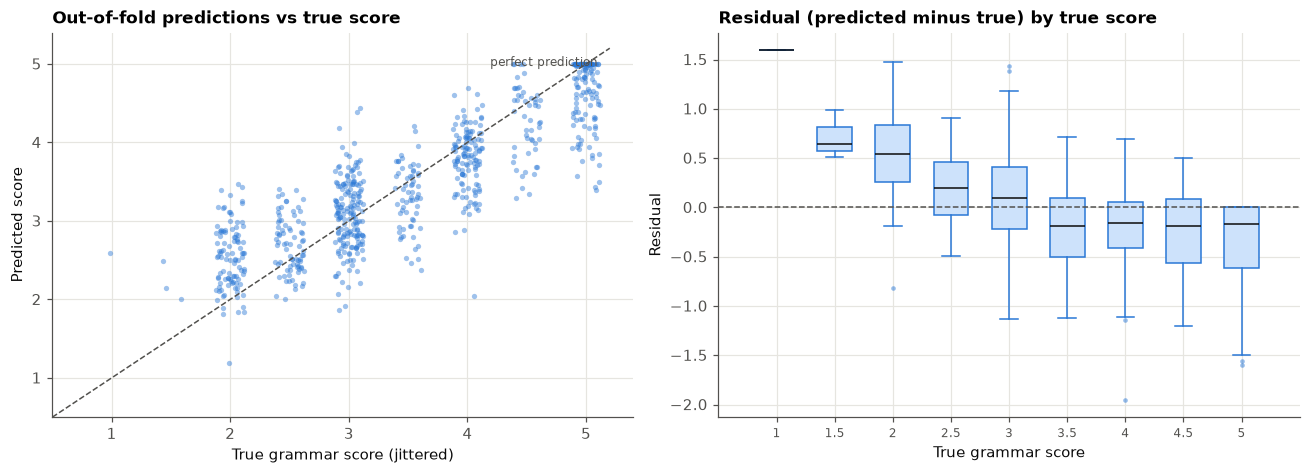

In [16]:
rng = np.random.default_rng(SEED)
jitter = rng.uniform(-0.12, 0.12, len(y))  # spread the discrete true scores so points do not overlap

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.4))
ax1.scatter(y + jitter, oof, s=12, color=BLUE, alpha=0.45, linewidths=0)
ax1.plot([0.5, 5.2], [0.5, 5.2], color=MUTED, linestyle="--", linewidth=1)
ax1.annotate("perfect prediction", (5.1, 5.1), ha="right", va="top", color=MUTED, fontsize=8)
ax1.set(title="Out-of-fold predictions vs true score", xlabel="True grammar score (jittered)",
        ylabel="Predicted score", xlim=(0.5, 5.4), ylim=(0.5, 5.4))

residual = oof - y
ax2.boxplot([residual[y == s] for s in scores], positions=scores, widths=0.3, patch_artist=True,
            boxprops=dict(facecolor=LIGHT_BLUE, edgecolor=BLUE), medianprops=dict(color=INK),
            whiskerprops=dict(color=BLUE), capprops=dict(color=BLUE),
            flierprops=dict(marker="o", markersize=3, markerfacecolor=BLUE, markeredgecolor="none", alpha=0.5))
ax2.axhline(0, color=MUTED, linestyle="--", linewidth=1)
ax2.set(title="Residual (predicted minus true) by true score", xlabel="True grammar score", ylabel="Residual")
ax2.set_xticks(scores, [f"{s:g}" for s in scores], fontsize=8)
fig.tight_layout()
plt.show()

Low scores are over-predicted and high scores under-predicted: the model pulls towards the middle of the scale, where most clips are. 69% of out-of-fold predictions are within 0.5 of the true score and 94% within 1.0.

## 10. Interpretation

Embedding dimensions have no individual meaning, so interpretation uses the hand-crafted features and, for the blend, the weight of each group.

- left: correlation of each hand-crafted feature with the score, one at a time
- right: weights of a ridge trained on the hand-crafted features alone (standardised, so a weight is the change in predicted score per standard deviation of the feature, others held fixed; correlated features share weight)

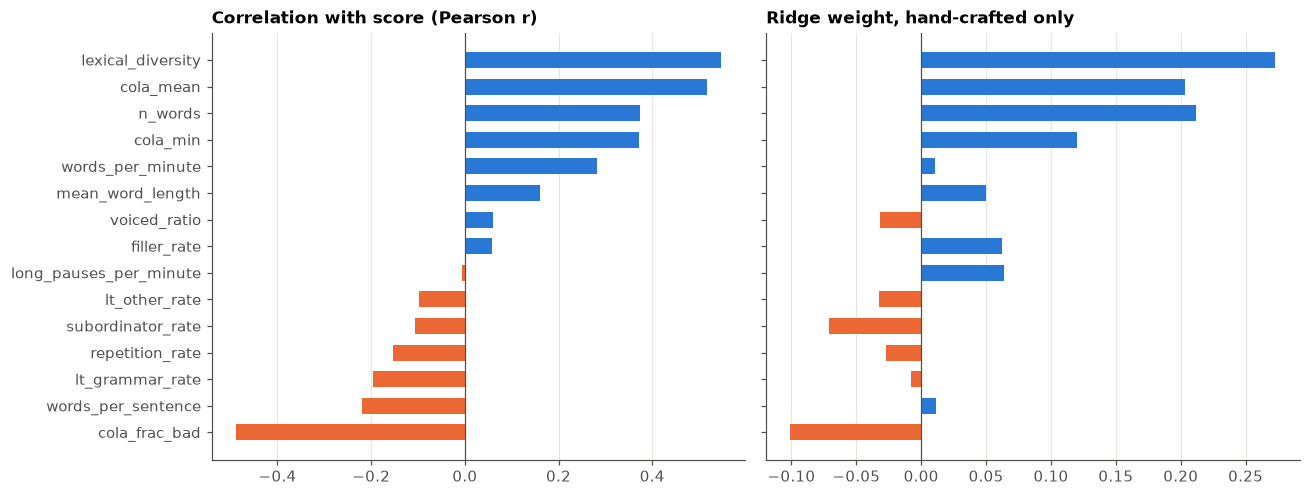

In [17]:
hc_model = make_model().fit(hc_train.to_numpy(dtype=float), y)
weights = pd.Series(hc_model[-1].coef_, index=hc_train.columns).reindex(corr.index)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
for ax, values, title in [(ax1, corr, "Correlation with score (Pearson r)"),
                          (ax2, weights, "Ridge weight, hand-crafted only")]:
    ax.barh(values.index, values.values, color=[ORANGE if v < 0 else BLUE for v in values.values], height=0.6)
    ax.axvline(0, color=MUTED, linewidth=0.8)
    ax.set(title=title)
    ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

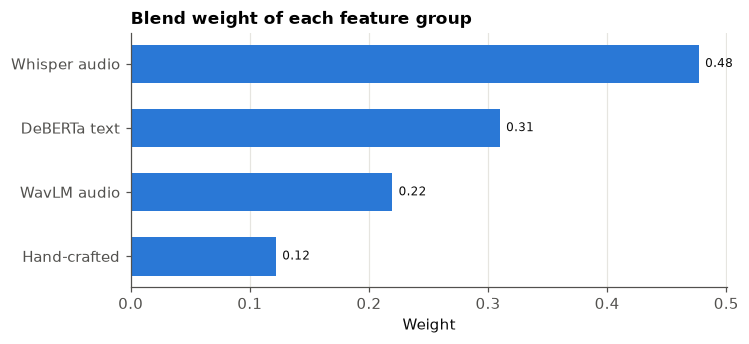

In [18]:
if isinstance(final_model, GroupBlend):
    group_weights = pd.Series(final_model.weights_.coef_, index=chosen_groups).sort_values()
    fig, ax = plt.subplots(figsize=(7, 0.5 * len(group_weights) + 1))
    ax.barh(group_weights.index, group_weights.values, color=BLUE, height=0.6)
    for i, v in enumerate(group_weights.values):
        ax.annotate(f"{v:.2f}", (v, i), xytext=(4, 0), textcoords="offset points", va="center", color=INK, fontsize=8)
    ax.set(title="Blend weight of each feature group", xlabel="Weight")
    ax.grid(axis="y", visible=False)
    plt.show()
else:
    print("Final model is a single ridge; no group weights to show.")

## 11. Submission

`sample_submission.csv` lists a mix of train, test and unknown ids, so it is only used for its column names. The submission has one row per clip in `test.csv`, in the same order, with predictions clipped to 0-5.

In [19]:
test_pred = predict_clipped(final_model, X_test)
submission = write_submission(clips.loc[~is_train, "file_id"], test_pred, sub_columns, OUTPUT_DIR / "submission.csv")
print(f"Wrote outputs/submission.csv: {len(submission)} rows")
display(submission.head())

pd.DataFrame({"file_id": train["file_id"], "label": y, "oof_pred": oof}).to_csv(OUTPUT_DIR / "oof_predictions.csv", index=False)
ablation.to_csv(OUTPUT_DIR / "cv_results.csv")

Wrote outputs/submission.csv: 216 rows


,filename,label
0,audio_128.wav,3.057
1,audio_156.wav,4.075
2,audio_19.wav,4.555
3,audio_108.wav,2.024
4,audio_206.wav,2.116


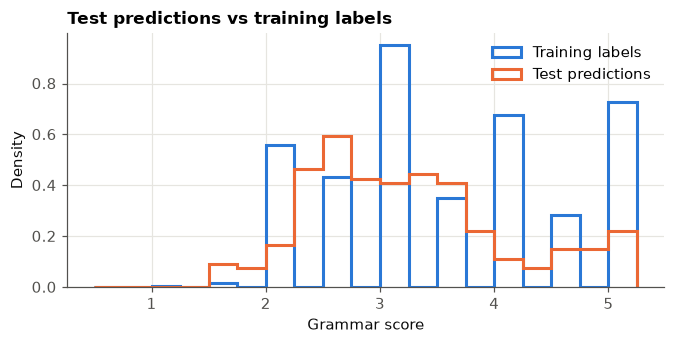

In [20]:
bins = np.linspace(0.5, 5.25, 20)
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(y, bins=bins, density=True, histtype="step", linewidth=2, color=BLUE, label="Training labels")
ax.hist(test_pred, bins=bins, density=True, histtype="step", linewidth=2, color=ORANGE, label="Test predictions")
ax.set(title="Test predictions vs training labels", xlabel="Grammar score", ylabel="Density")
ax.legend()
plt.show()

## 12. Summary

| | RMSE | Pearson r |
|---|---|---|
| 5-fold CV, final model | 0.512 | 0.864 |
| Training set (final model) | 0.371 | 0.933 |
| Predict the mean | 1.014 | |
| Public leaderboard, v1 (one ridge on hand-crafted + DeBERTa + WavLM) | 0.402 | |
| Public leaderboard, v2 (final model) | 0.381 | |

**Approach.** Whisper `medium.en` transcribes each clip on a Kaggle GPU. Inputs are 15 hand-crafted features tied to the rubric, a DeBERTa embedding of the transcript, and two audio embeddings (WavLM, Whisper large-v3 encoder). One ridge per group, blended with non-negative weights; predictions clipped to 0-5.

**Preprocessing.** Audio resampled to 16 kHz mono. Whisper repetition loops collapsed (5 clips). The score-0 batch (37 clips) removed: separable from everything else and absent from test. Missing values filled with the training median and all columns standardised inside the model, so nothing leaks from validation folds.

**Findings.**
- Audio carries most of the signal: Whisper encoder alone reaches 0.549 CV RMSE, and gets the largest blend weight (0.48). Text adds to it (DeBERTa 0.31).
- Hand-crafted features are the weakest group alone (0.753) but the easiest to read: lexical diversity and CoLA acceptability track the score most closely; error rates and repetitions go the other way.
- CV is pessimistic compared with the leaderboard (v1: 0.53 CV, 0.40 public). It is used to compare versions, not to predict the leaderboard.

**Limits and next steps.** The model is cautious at the ends of the scale. Whisper smooths over some disfluencies and small errors. Next options, each kept only if CV improves: fine-tuning an audio model end-to-end, and better transcripts from a larger Whisper model with temperature fallback.